In [ ]:
import pandas as pd
import numpy as np
from numpy._core import numeric
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

url = "https://drive.google.com/uc?export=download&id=1jIiNiySgPaNqBT7HP2CXoUKPjLDaXZwO"
df = pd.read_csv(url)

# Level 1 :Basic

## Part A: Loading and understanding the dataset

### Loading the dataset using pandas

In [ ]:
import pandas as pd
url = "https://drive.google.com/uc?export=download&id=1jIiNiySgPaNqBT7HP2CXoUKPjLDaXZwO"
df = pd.read_csv(url)

### Displaying the dataset shape, columns and data types

In [ ]:
print(df.shape) #Will give the shape of the dataset
print(df.info()) #Will give the names of columns and type of the data in that column

(130663, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130663 entries, 0 to 130662
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_name       130663 non-null  object 
 1   track_id          130663 non-null  object 
 2   track_name        130662 non-null  object 
 3   acousticness      130663 non-null  float64
 4   danceability      130663 non-null  float64
 5   duration_ms       130663 non-null  int64  
 6   energy            130663 non-null  float64
 7   instrumentalness  130663 non-null  float64
 8   key               130663 non-null  int64  
 9   liveness          130663 non-null  float64
 10  loudness          130663 non-null  float64
 11  mode              130663 non-null  int64  
 12  speechiness       130663 non-null  float64
 13  tempo             130663 non-null  float64
 14  time_signature    130663 non-null  int64  
 15  valence           130663 non-null  float64
 16  popular

### Indentifying numerical and categorical features

In [ ]:
#To identify numerical columns
n_columns = df.select_dtypes(include=['int64','float64']).columns
print("Numerical columns are: ", n_columns)
print()

#To identify categorical columns
c_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns are: ", c_columns)

Numerical columns are:  Index(['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence', 'popularity'],
      dtype='object')

Categorical columns are:  Index(['artist_name', 'track_id', 'track_name'], dtype='object')


## Part B: Probability and statistic analysis

### Computing mean, variance, and standard deviation of key audio features

In [ ]:
print("Mean of numeric data is as followed: ")
print()
print(df.mean(numeric_only=True))
print()
print("Variance of numeric data is as followed: ")
print()
print(df.var(numeric_only=True))
print()
print("Standard deviation of data is as followed: ")
print()
print(df.std(numeric_only=True))

Mean of numeric data is as followed: 

acousticness             0.342500
danceability             0.581468
duration_ms         212633.124098
energy                   0.569196
instrumentalness         0.224018
key                      5.231894
liveness                 0.194886
loudness                -9.974006
mode                     0.607739
speechiness              0.112015
tempo                  119.473353
time_signature           3.878986
valence                  0.439630
popularity              24.208988
dtype: float64

Variance of numeric data is as followed: 

acousticness        1.194674e-01
danceability        3.612922e-02
duration_ms         1.516717e+10
energy              6.776217e-02
instrumentalness    1.298362e-01
key                 1.297946e+01
liveness            2.813446e-02
loudness            4.282890e+01
mode                2.383941e-01
speechiness         1.545719e-02
tempo               9.096036e+02
time_signature      2.646105e-01
valence             6.712217e-

### to analyse the distributions of energy, danceability and tempo

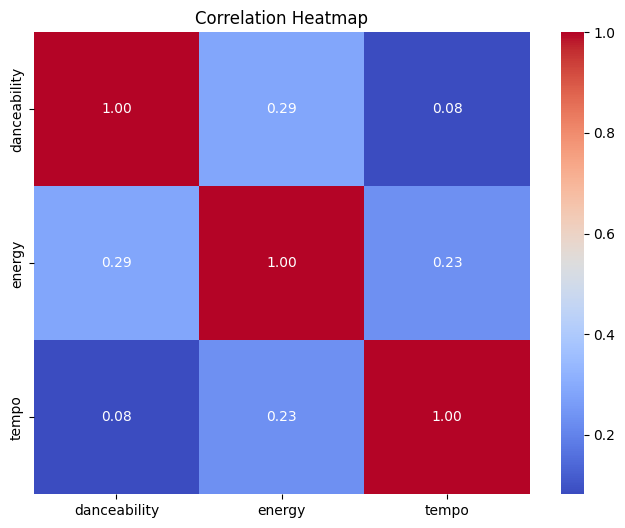

In [ ]:
#We will analse this distributions via graphs
numerical_features = ['danceability', 'energy', 'tempo']

# correlation matrix
corr_matrix = df[numerical_features].corr()

# Plotting heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Observation of the correlation heatmap

Observation:

The heatmap shows that danceability and energy have a small positive link (about 0.29), so songs that are more energetic are often a bit more danceable.
Energy and tempo also have a weak positive link (0.23), meaning faster songs are slightly more energetic.
Danceability and tempo have almost no link (0.08), so how fast a song is does not strongly affect how danceable it feels.


## Part C: EDA

### Handling missing values

#### To handle the missing values, firat we need to find out if there's any missing value in the given dataset

In [ ]:
print(df.isnull().sum())
print()#To find total number of missing values in each column

rows_with_missing = df[df.isnull().any(axis=1)] #to find missing values in each row
print(rows_with_missing)
df['track_name'] = df['track_name'].fillna("Unknown track") #Missingdata (NaN) to be defined as Unknown track

artist_name         0
track_id            0
track_name          1
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
popularity          0
dtype: int64

      artist_name                track_id track_name  acousticness  \
54836  VELVETEARS  2vPmLy7QuLoFfEumm6vAbV        NaN         0.418   

       danceability  duration_ms  energy  instrumentalness  key  liveness  \
54836         0.694       148532   0.407          0.000137    5    0.0785   

       loudness  mode  speechiness   tempo  time_signature  valence  \
54836   -14.235     0       0.0332  90.023               4    0.151   

       popularity  
54836          24  


### Performing feature scaling on the dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
features = [ "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)
print(X_scaled.head())

   danceability    energy  loudness  speechiness  acousticness  \
0      0.849826 -0.884312  0.350838     2.388752     -0.974080   
1      1.391714 -0.046852  0.414862     2.774832     -0.920325   
2      0.113279  0.590848  0.624050    -0.535807     -0.918589   
3      1.149706  0.037663 -0.327610    -0.337136     -0.905859   
4      1.060268  0.855916 -0.046299    -0.369310     -0.990817   

   instrumentalness  liveness   valence     tempo  duration_ms  
0         -0.621709 -0.677783 -1.241440  2.800232     0.209005  
1         -0.621709  0.543208 -0.264902  1.310884     0.017595  
2         -0.621709 -0.670628 -0.222443 -0.149450    -0.598598  
3          1.909328 -0.569277  0.777254  0.117033    -0.708476  
4          1.814969 -0.963952  1.885026  0.019020    -0.719560  


### Creating visual representations using Malplotlib and Seaborn

#### Energy distribution

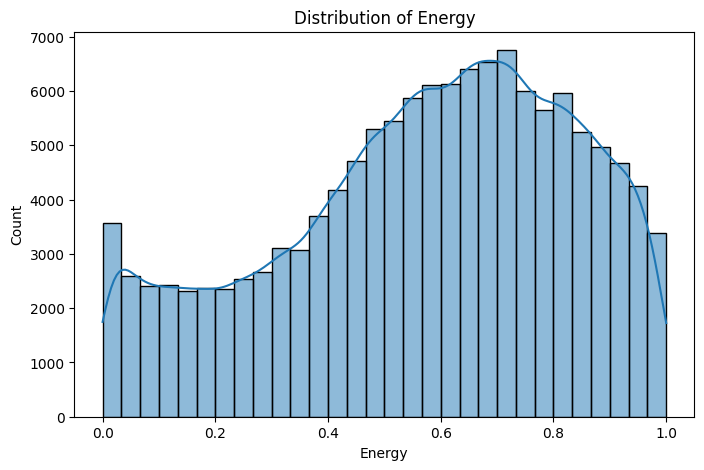

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['energy'], bins=30, kde=True)
plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

#### Danceability distributions

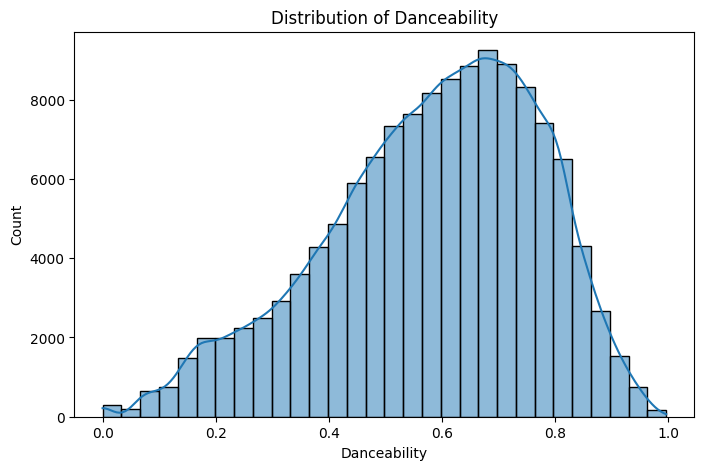

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['danceability'], bins=30, kde=True)
plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Count")
plt.show()

#### Tempo distribution

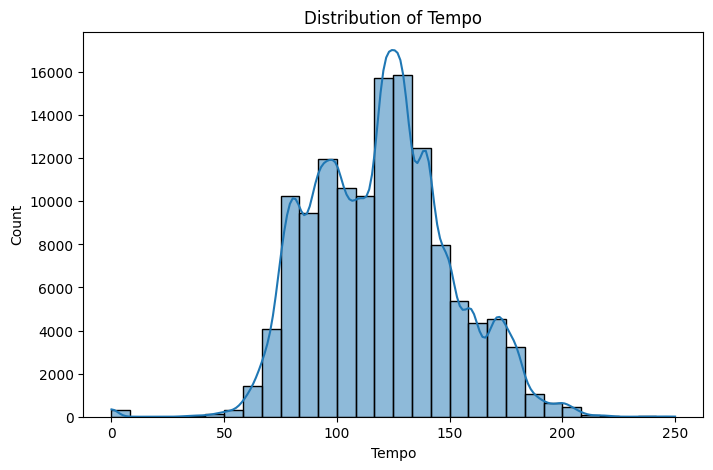

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['tempo'], bins=30, kde=True)
plt.title("Distribution of Tempo")
plt.xlabel("Tempo")
plt.ylabel("Count")
plt.show()

#### Correlation heatmap

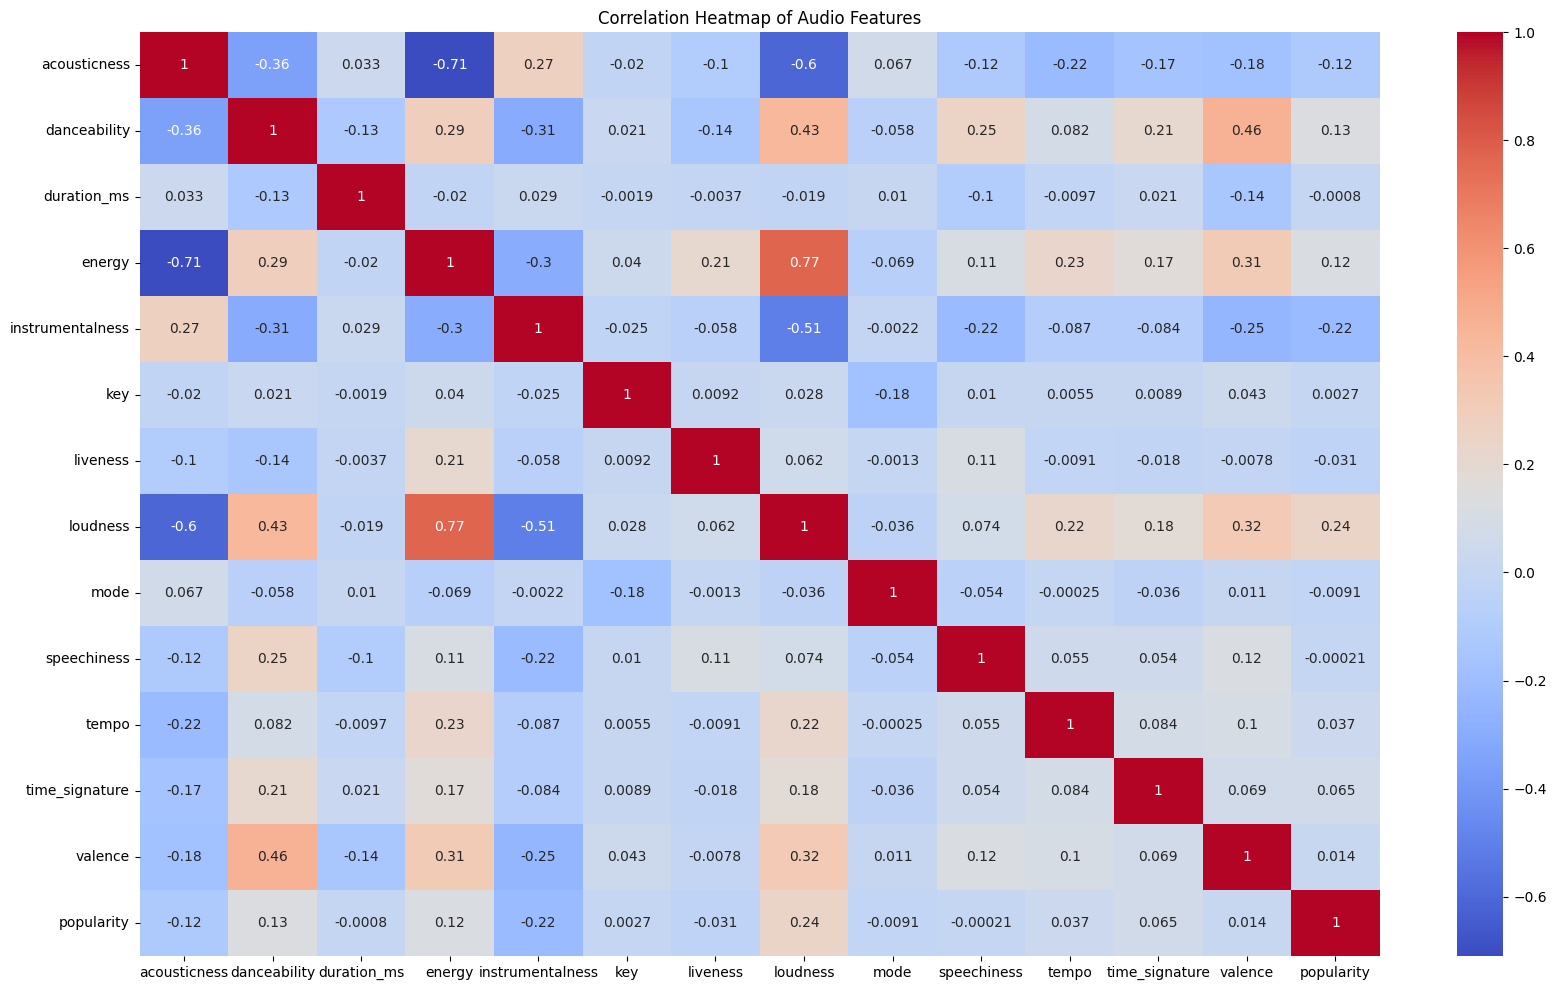

In [ ]:
plt.figure(figsize=(20,12))

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Audio Features")
plt.show()

## Part D: Supervised learning

### Defining genre

In [ ]:
def mood_label(valence):
    if valence < 0.18:
        return 'Very Sad'
    elif valence < 0.33:
        return 'Sad'
    elif valence < 0.52:
        return 'Neutral'
    elif valence < 0.75:
        return 'Happy'
    else:
        return 'Very Happy'

df['mood'] = df['valence'].apply(mood_label)

print(df[['valence', 'mood']].head())

   valence        mood
0    0.118    Very Sad
1    0.371     Neutral
2    0.382     Neutral
3    0.641       Happy
4    0.928  Very Happy


#### Feature comparison across moods (Part c question)

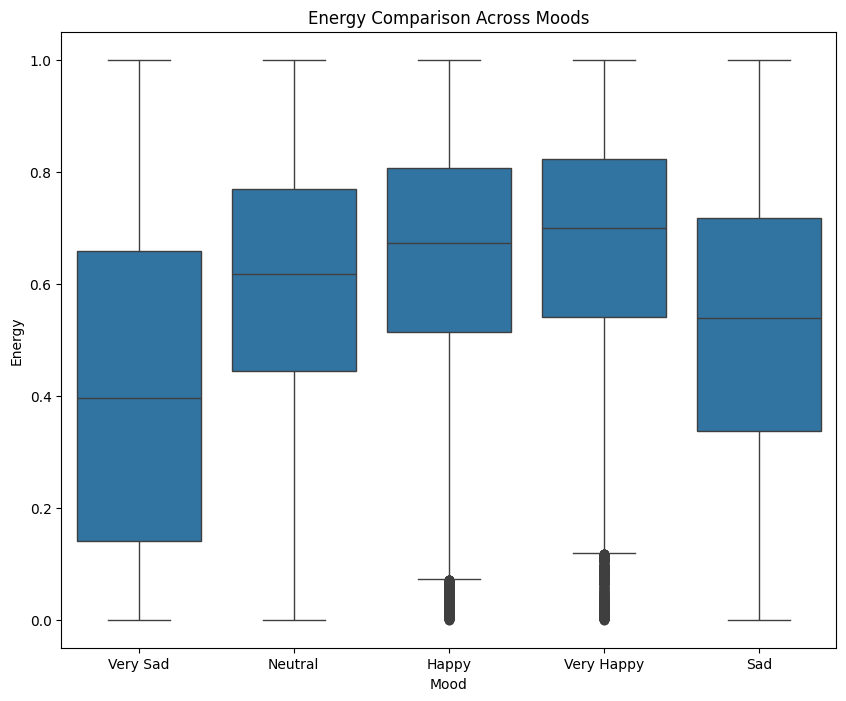

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.boxplot(x='mood', y='energy', data=df)
plt.title('Energy Comparison Across Moods')
plt.xlabel('Mood')
plt.ylabel('Energy')
plt.show()

### Splitting the data into training and testing set

In [ ]:
def mood_label(valence):
    if valence < 0.18:
        return 'Very Sad'
    elif valence < 0.33:
        return 'Sad'
    elif valence < 0.52:
        return 'Neutral'
    elif valence < 0.75:
        return 'Happy'
    else:
        return 'Very Happy'


df['mood'] = df['valence'].apply(mood_label)

# Select all numeric columns
X = df.select_dtypes(include='number').drop(columns=['valence'])
y = df['mood']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train, y_train)

print("Your model has been trained successfully")

Your model has been trained successfully


### Accuracy and confusion matrix

Accuracy: 0.36115256572150156

% Accuracy =  36.11525657215016 %

Confusion Matrix:
 [[1555  915  863 2232  590]
 [1295 1121 1381 1447  942]
 [ 629  789 1441  770 1257]
 [ 656  346  253 2362  232]
 [ 287  352  992  467 2959]]


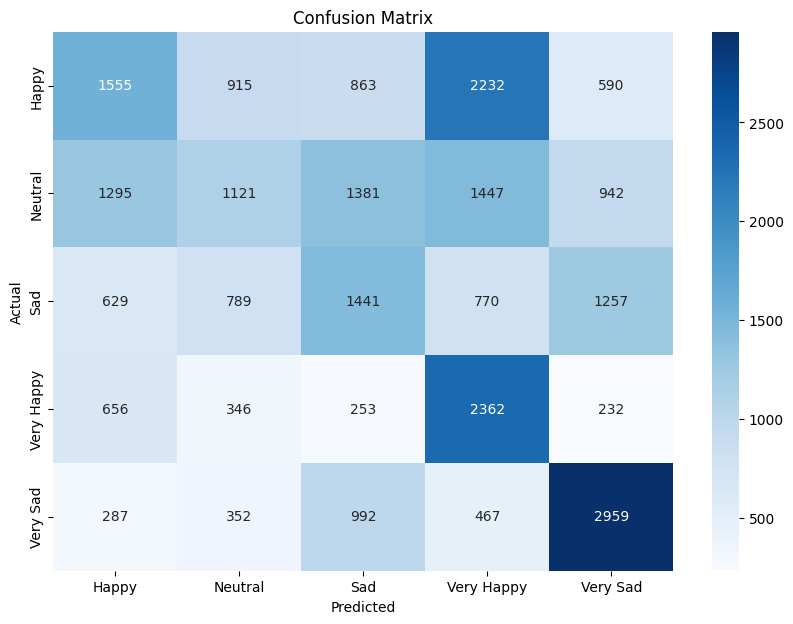

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# to Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = model.predict(X_test)

per_accuracy = (accuracy*100)
print()
print('% Accuracy = ', per_accuracy, '%')
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# to Print raw confusion matrix
print()
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Part E: Model testing on a new song sample

### Selecting a song

In [ ]:
song_name = "Faded"
artist_name = "Alan Walker"

print("Selected Song:", song_name, "by", artist_name)

Selected Song: Faded by Alan Walker


### Obtaining it's audio features manually using a spotify audio feature viewer

In [ ]:
song_data = {
    'danceability': 0.468,
    'energy': 0.627,
    'loudness': -5.085,
    'speechiness': 0.0476,
    'acousticness': 0.0281,
    'instrumentalness': 7.97E-06,
    'liveness': 0.11,
    'tempo': 179.642,
    'duration_ms': 212107,
    'key':6,
    'mode':1,
    'time_signature':4,
    'popularity':81
}

# Convert to DataFrame
song_df = pd.DataFrame([song_data])
song_df = song_df.reindex(columns=X.columns)

print("Audio features of the song selected: ")
print(song_df)

Audio features of the song selected: 
   acousticness  danceability  duration_ms  energy  instrumentalness  key  \
0        0.0281         0.468       212107   0.627          0.000008    6   

   liveness  loudness  mode  speechiness    tempo  time_signature  popularity  
0      0.11    -5.085     1       0.0476  179.642               4          81  


### Inputing the fetures into the trained model

In [ ]:
song_scaled = scaler.transform(song_df)
print("All the features has been scaled: ", song_scaled)

All the features has been scaled:  [[-0.90961985 -0.59696262 -0.00427206  0.2220579  -0.62168712  0.21320355
  -0.50608077  0.74705702  0.8033948  -0.51811152  1.99501336  0.23525146
   2.88087452]]


### Predicting and interpreting the output

In [ ]:
predicted_mood = model.predict(song_scaled)

print("Predicted Mood:", predicted_mood[0])

probabilities = model.predict_proba(song_scaled)
prob_df = pd.DataFrame(probabilities, columns=model.classes_)

print("\nPrediction Probabilities:")
print(prob_df)



valence_value = 0.159
print("\nValence Value:", valence_value)
print("Expected Mood from Valence:", mood_label(valence_value))

Predicted Mood: Sad

Prediction Probabilities:
     Happy   Neutral       Sad  Very Happy  Very Sad
0  0.12544  0.243427  0.362313    0.041642  0.227178

Valence Value: 0.159
Expected Mood from Valence: Very Sad


The prediction of the song is nearer to be accurate but it overlaps nearly.

# Level 2: Advanced

## Part F: Unsupervised Learning

### Applying K-Means clustering

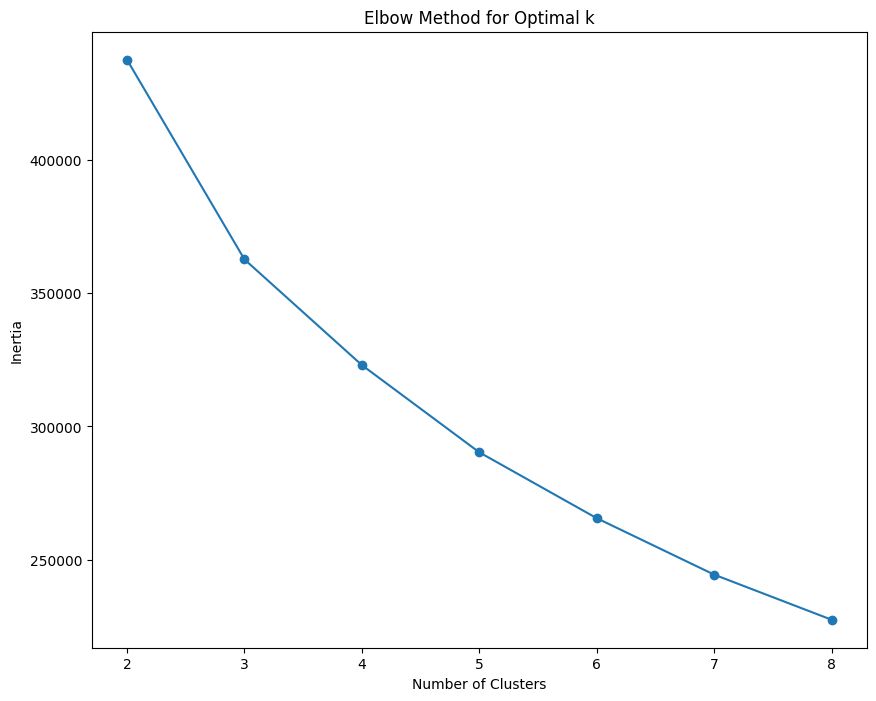

In [ ]:
cluster_features = ['danceability', 'energy', 'tempo', 'valence', 'acousticness']
X_cluster = df[cluster_features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


inertia = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10,8))
plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()



#### After finding the optimal K from the plot which is to be 3, we will use it further

In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('Cluster')[cluster_features].mean()
print("\nCluster Summary (average feature values per cluster):")
print(cluster_summary)



Cluster Summary (average feature values per cluster):
         danceability    energy       tempo   valence  acousticness
Cluster                                                            
0            0.296531  0.176359   98.864388  0.156189      0.858002
1            0.527805  0.725769  161.068795  0.485243      0.153335
2            0.733024  0.693960  113.592999  0.704100      0.195101
3            0.599592  0.353134  114.894433  0.461732      0.743751
4            0.590745  0.669777  112.710095  0.266268      0.112702


#### We will be naming each clusters

In [ ]:
cluster_labels = {0: 'Very sad', 1:'Very happy', 2:'Happy', 3: 'Neutral' , 4:'Sad'}
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

print(df[['Cluster', 'Cluster_Label']].head(10))

# Or print a summary of all clusters
print("\nNumber of songs per cluster:")
print(df['Cluster_Label'].value_counts())

   Cluster Cluster_Label
0        1    Very happy
1        1    Very happy
2        4           Sad
3        2         Happy
4        2         Happy
5        2         Happy
6        2         Happy
7        4           Sad
8        2         Happy
9        2         Happy

Number of songs per cluster:
Cluster_Label
Happy         36009
Sad           34650
Very happy    21693
Neutral       20793
Very sad      17518
Name: count, dtype: int64


### Visualising the clusters

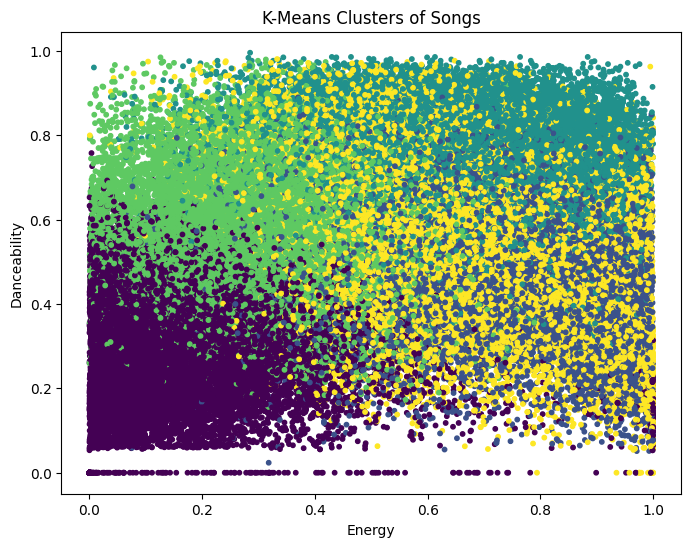

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['energy'], df['danceability'], c=df['Cluster'], cmap='viridis', s=10)
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.title('K-Means Clusters of Songs')
plt.show()

### Comparing clusters with the actual labels

Cluster vs Actual Mood Table:

mood           Happy  Neutral    Sad  Very Happy  Very Sad
Cluster_Label                                             
Happy          17142     4575     11       14281         0
Neutral         5422     6923   4243        2327      1878
Sad             1038    11098  12095           0     10419
Very happy      6437     7199   3608        2743      1706
Very sad         287     1564   4184          17     11466


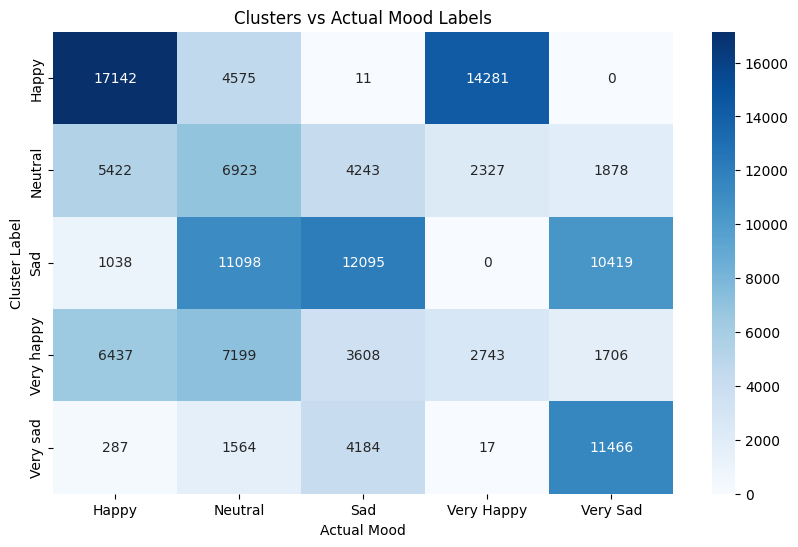

In [ ]:
df['mood'] = df['valence'].apply(mood_label)
comparison = pd.crosstab(df['Cluster_Label'], df['mood'])
print("Cluster vs Actual Mood Table:\n")
print(comparison)


plt.figure(figsize=(10,6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Actual Mood')
plt.ylabel('Cluster Label')
plt.title('Clusters vs Actual Mood Labels')
plt.show()

### Interpreting whether the songs naturally group by mood

Songs with similar emotional characteristics such as Happy and Very Happy were grouped together, while Sad and Very Sad songs formed separate clusters. Happy song happy and sad because of very thin line difference between them. Some overlap was observed in Neutral songs, which is expected due to gradual emotional transitions. Although silhouette analysis suggested k = 3 as optimal, k = 5 was selected for better interpretability and comparison with mood categories. Overall, the results indicate that songs were naturally grouped by mood based on audio features.

## Part G: Feature Engineering and Optimization

### Experiment with feature selection

In [ ]:
# Select numeric audio features only
features = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence', 'tempo'
]

# Check variance of features
df[features].var()

# Remove very low-variance features if needed
selected_features = df[features].loc[:, df[features].var() > 0.02].columns.tolist()

# Final feature set to use
print("Selected features:", selected_features)

Selected features: ['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


### Tuning model hyperparameters

In [ ]:
# Select features
features = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence', 'tempo' ]


X = df[features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hyperparameter tuning
k_values = range(2, 9)
n_init_values = [10, 15, 20]

best_score = -1
best_params = {}

for k in k_values:
    for n in n_init_values:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=n
        )
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)

        if score > best_score:
            best_score = score
            best_params = {
                'n_clusters': k,
                'n_init': n
            }

print("Best parameters:", best_params)
print("Best silhouette score:", best_score)

Best parameters: {'n_clusters': 2, 'n_init': 10}
Best silhouette score: 0.3089349063863509


### Comparing performance before and after optimization

In [ ]:
# K-Means before optimization
kmeans_before = KMeans(n_clusters=5, n_init=10, random_state=42)
labels_before = kmeans_before.fit_predict(X_scaled)

# Silhouette score before optimization
silhouette_before = silhouette_score(X_scaled, labels_before)

print("Before Optimization:")
print("Number of clusters:", 5)
print("Silhouette Score:", silhouette_before)

# K-Means after optimization
kmeans_after = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_after = kmeans_after.fit_predict(X_scaled)

# Silhouette score after optimization
silhouette_after = silhouette_score(X_scaled, labels_after)

print("\nAfter Optimization:")
print("Number of clusters:", 2)
print("Silhouette Score:", silhouette_after)

print("\nPerformance Comparison:")
print("Silhouette Score Before Optimization:", silhouette_before)
print("Silhouette Score After Optimization:", silhouette_after)

Before Optimization:
Number of clusters: 5
Silhouette Score: 0.16707496665575758

After Optimization:
Number of clusters: 2
Silhouette Score: 0.3089349063863509

Performance Comparison:
Silhouette Score Before Optimization: 0.16707496665575758
Silhouette Score After Optimization: 0.3089349063863509
